# From Genesis to Chemistry: The Evolution of Structure

**"The void breathes, and matter condenses."**

In the previous notebook, we saw particles pop into existence. In this advanced simulation, we will witness the **birth of stability**.

We will demonstrate the FTD **Locking Mechanism** (Phase 11 Binding): 
1.  **Chaos:** High energy flux creates transient particles.
2.  **Nucleosynthesis:** Particles that find neighbors of the same sign form **Triads**.
3.  **Locking:** Triads resist entropy (decay). They become permanent matter.
4.  **Chemistry:** We will use a `ClusterAnalyzer` to count and classify these stable structures.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# Add repository root to path
current_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(current_dir, "../../"))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from ternary_matrix.model.grid import Universe
from ternary_matrix.physics import master_equation
from ternary_matrix.config import CONSTANTS

## 1. The Chemist Tool

We define a helper class to analyze our universe and find "Molecules" (connected components).

In [2]:
class UniverseChemist:
    def __init__(self, universe):
        self.universe = universe
        
    def analyze(self):
        # Identify Positive Matter Clusters
        pos_mask = (self.universe.states == 1)
        pos_labels, pos_count = label(pos_mask)
        
        # Identify Negative Matter Clusters
        neg_mask = (self.universe.states == -1)
        neg_labels, neg_count = label(neg_mask)
        
        # Analyze sizes
        structure_sizes = []
        if pos_count > 0:
            # bincount gives size of each label (0 is background)
            sizes = np.bincount(pos_labels.ravel())[1:]
            structure_sizes.extend(sizes)
            
        if neg_count > 0:
            sizes = np.bincount(neg_labels.ravel())[1:]
            structure_sizes.extend(sizes)
            
        return {
            "total_particles": np.count_nonzero(self.universe.states),
            "total_clusters": pos_count + neg_count,
            "sizes": structure_sizes
        }
    
    def print_report(self, t):
        stats = self.analyze()
        sizes = stats["sizes"]
        
        print(f"--- Epoch {t} ---")
        print(f"Total Particles: {stats['total_particles']}")
        print(f"Bound Structures: {stats['total_clusters']}")
        
        # Taxonomy
        singletons = sum(1 for s in sizes if s == 1)
        diatomics = sum(1 for s in sizes if s == 2)
        triads = sum(1 for s in sizes if s == 3)
        heavy_nuclei = sum(1 for s in sizes if s > 3)
        
        print(f"  Hydrogen (1): {singletons}")
        print(f"  Deuterium (2): {diatomics}")
        print(f"  Tritium/Helium (3): {triads}")
        print(f"  Heavy Matter (>3): {heavy_nuclei}")

## 2. Simulation Configuration: The Early Universe

We need a "Goldilocks" universe:
1.  **High C**: Allows rapid mixing.
2.  **Low Barrier (KB)**: Encourage particle creation.
3.  **High Decay**: Kill off singletons so only bound structures survive.

This creates a **Selection Pressure** for stability.

In [3]:
CONSTANTS.C = 0.5
CONSTANTS.ALPHA = 0.05      # Boosted coupling for demo
CONSTANTS.KB = 0.8          # Low creation threshold
CONSTANTS.DECAY_RATE = 0.1  # Harsh environment! Only the strong (locked) survive.
CONSTANTS.GRID_SIZE = 40    

universe = Universe(size=CONSTANTS.GRID_SIZE)
chemist = UniverseChemist(universe)

## 3. Phase I: Cosmic Inflation (The Injection)

We inject massive flux energy across the grid to simulate a hot, dense state.

In [4]:
# Random Flux Injection
np.random.seed(42)
noise = np.random.normal(0, 2.0, universe.flux.shape)
universe.flux += noise

print("Energy injected. The soup is hot.")

Energy injected. The soup is hot.


## 4. Phase II: Nucleosynthesis (Run Loop)

We run 100 ticks. Watch how the particle counts evolve.
Initially, you'll see a spike in "Hydrogen" (Singletons).
Then, as decay kicks in, singletons die, but "Triads" (3) and "Heavy Matter" (>3) should persist.

In [5]:
history_singletons = []
history_complex = []

for t in range(1000):
    master_equation.tick(universe)
    
    # Gather stats
    stats = chemist.analyze()
    sizes = stats["sizes"]
    singletons = sum(1 for s in sizes if s == 1)
    complex_matter = sum(1 for s in sizes if s >= 3)
    
    history_singletons.append(singletons)
    history_complex.append(complex_matter)
    
    if t % 10 == 0:
        chemist.print_report(t)

print("Simulation Complete.")

--- Epoch 0 ---
Total Particles: 0
Bound Structures: 0
  Hydrogen (1): 0
  Deuterium (2): 0
  Tritium/Helium (3): 0
  Heavy Matter (>3): 0
DEBUG: Genesis events - Pos: 22440, Neg: 22347
DEBUG: Genesis events - Pos: 24857, Neg: 24856
DEBUG: Genesis events - Pos: 21451, Neg: 21653
DEBUG: Genesis events - Pos: 19576, Neg: 19734
DEBUG: Genesis events - Pos: 18008, Neg: 18031
DEBUG: Genesis events - Pos: 16601, Neg: 16421
DEBUG: Genesis events - Pos: 13200, Neg: 13334
DEBUG: Genesis events - Pos: 12206, Neg: 12224
DEBUG: Genesis events - Pos: 9521, Neg: 9687
DEBUG: Genesis events - Pos: 7873, Neg: 7938
--- Epoch 10 ---
Total Particles: 7431
Bound Structures: 5597
  Hydrogen (1): 4484
  Deuterium (2): 711
  Tritium/Helium (3): 239
  Heavy Matter (>3): 163
DEBUG: Genesis events - Pos: 6213, Neg: 6041
DEBUG: Genesis events - Pos: 4681, Neg: 4779
DEBUG: Genesis events - Pos: 3257, Neg: 3274
DEBUG: Genesis events - Pos: 2355, Neg: 2407
DEBUG: Genesis events - Pos: 1468, Neg: 1528
DEBUG: Genesis 

## 5. Analysis: evolution of Complexity

Let's plot the "Era of Nucleosynthesis".

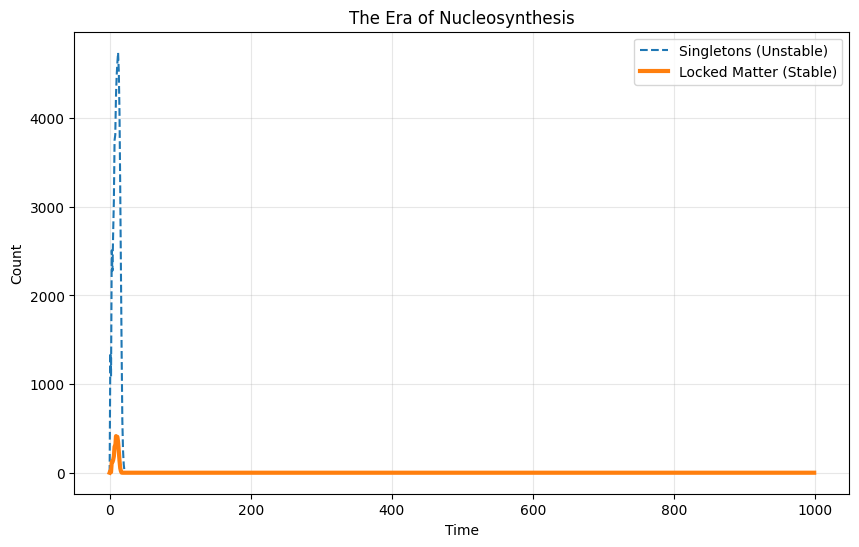

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history_singletons, label="Singletons (Unstable)", linestyle="--")
plt.plot(history_complex, label="Locked Matter (Stable)", linewidth=3)
plt.title("The Era of Nucleosynthesis")
plt.xlabel("Time")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Visualizing the "Molecules"

Let's look at a 3D Voxels plot of the surviving stable matter.

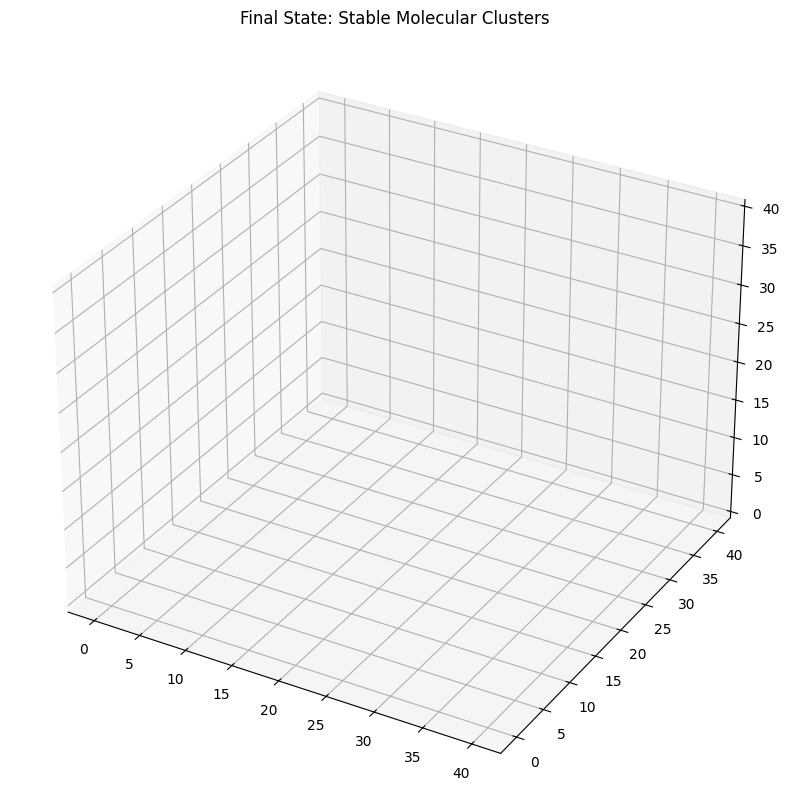

In [7]:
states = universe.states

# Create voxel colors
colors = np.empty(states.shape, dtype=object)
colors[states == 1] = 'red'    # Matter
colors[states == -1] = 'blue'  # Antimatter

ax = plt.figure(figsize=(10, 10)).add_subplot(projection='3d')
ax.voxels(states != 0, facecolors=colors, edgecolor='k', alpha=0.8)
ax.set_title("Final State: Stable Molecular Clusters")

plt.show()